In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import pacf

In [4]:
# Xa = [x1, x2] Xa in unknown_prob_dist1
# Xe = [x1, x2, x3]
Xc = [0.533,0.666,0.5]
# w = s s in unknown_porb_dist2
# Xa and s are independent

df = pd.read_csv('Y_out_example.csv')
df = df.iloc[1:]
df

,y1,y2,y3,y4,y5,y6,sample_no
1,0.059999,0.002995,0.005539,44.993498,22.150530,18.684838,0
2,0.060057,0.003001,0.005545,45.073874,22.190100,18.718216,0
3,0.058141,0.002788,0.005325,42.363677,20.855855,17.592729,0
4,0.057153,0.002678,0.005211,43.366456,21.349529,18.009162,0
5,0.055056,0.002445,0.004969,41.726468,20.542154,17.328110,0
...,...,...,...,...,...,...,...
5996,3.350000,3.219919,3.339492,266.394815,131.147535,110.628071,99
5997,3.350000,3.232927,3.340543,260.266228,128.130400,108.083000,99
5998,3.350000,3.244634,3.341489,306.062037,150.675912,127.101020,99
5999,3.350000,3.255171,3.342340,273.961008,134.872411,113.770149,99


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 1 to 6000
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1         6000 non-null   float64
 1   y2         6000 non-null   float64
 2   y3         6000 non-null   float64
 3   y4         6000 non-null   float64
 4   y5         6000 non-null   float64
 5   y6         6000 non-null   float64
 6   sample_no  6000 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 328.3 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
y1,6000.0,2.583254,1.205684,0.0,1.727971,3.350000,3.350000,3.350000
y2,6000.0,1.973615,1.355365,0.0,0.380822,2.313034,3.350000,3.350000
y3,6000.0,2.076951,1.344467,0.0,0.485163,2.612641,3.350000,3.350000
y4,6000.0,287.112332,239.491164,0.0,118.189199,212.694718,366.747245,1322.811793
y5,6000.0,141.346875,117.902730,0.0,58.185150,104.710701,180.551552,651.227037
y6,6000.0,119.231613,99.455560,0.0,49.081447,88.327569,152.302289,549.335454
sample_no,6000.0,49.500000,28.868476,0.0,24.750000,49.500000,74.250000,99.000000


In [13]:
def multiple_histplots(df):
    _, axs = plt.subplots(2, 3, figsize=(15, 10))
    colors = sns.color_palette('husl', 6)
    numeric_columns = df.select_dtypes(include='number').columns[:6]

    for i, (row, col) in enumerate([(r, c) for r in range(2) for c in range(3)]):
        if i < len(numeric_columns):
            sns.histplot(data=df, x=numeric_columns[i], ax=axs[row][col], color=colors[i], kde=False, stat='density')
            sns.kdeplot(data=df, x=numeric_columns[i], ax=axs[row][col], color='black')
            
            axs[row][col].set_title(f'Histogram of {numeric_columns[i]}')
        else:
            axs[row][col].axis('off')

    plt.tight_layout()
    plt.show()

def plot_ts(df, sample_no, to_return = False):
    sample_df = df[df['sample_no'] == sample_no].drop('sample_no', axis=1)
    _, axs = plt.subplots(2, 3, figsize=(15, 10))
    colors = sns.color_palette('husl', 6)
    
    for i, (row, col) in enumerate([(r, c) for r in range(2) for c in range(3)]):
        if i < sample_df.shape[1]: 
            axs[row][col].plot(sample_df.iloc[:, i], color=colors[i])
            axs[row][col].set_title(f'Univariate y{i + 1}')
            axs[row][col].set_xlabel('Time')
            axs[row][col].set_ylabel('Value')
        else:
            axs[row][col].axis('off')  

    plt.tight_layout()
    plt.show()
    
    if to_return:
        return sample_df

def correlation_ts(df, sample_no = None, to_return = False, ignore = False):
    if sample_no is None:
        sample_no = np.random.choice(np.arange(max(df['sample_no'] + 1)), 1)[0]
    sample_df = df[df['sample_no'] == sample_no].drop('sample_no', axis=1)
    
    if not ignore:
        plt.figure(figsize=(10, 8))
        sns.heatmap(sample_df.corr(), cmap = 'coolwarm', annot=True, fmt=".2f", center=0, linewidths=0.5)
        plt.show()
    
    if to_return:
        return sample_df.corr()

def correlation_distribution(df, to_return=False):
    all_correlations = {}
    
    columns = [col for col in df.columns if col != 'sample_no']
    
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            yi, yj = columns[i], columns[j]
            correlations = []
            
            for sample_no in set(df['sample_no']):
                sample_df = df[df['sample_no'] == sample_no].drop('sample_no', axis=1)
                
                # Check if either yi or yj has only one unique value in this sample
                if sample_df[yi].nunique() == 1 or sample_df[yj].nunique() == 1:
                    print(f"Skipping {yi} vs {yj} for sample {sample_no} due to constant value.")
                    continue
                
                corr_value = sample_df[yi].corr(sample_df[yj])
                correlations.append(corr_value)
            
            if correlations:  # Proceed only if there are valid correlations
                all_correlations[(yi, yj)] = correlations
                
                plt.figure(figsize=(10, 6))
                sns.histplot(correlations, kde=True, color='blue', bins=20)
                plt.title(f'Distribution of Correlations for {yi} vs {yj}.\nTotal samples: {len(correlations)}')
                plt.xlabel('Correlation Value')
                plt.ylabel('Frequency')
                plt.show()
    
    if to_return:
        return all_correlations


def plot_acf_pacf(df, sample_no = None, lags=10):
    if sample_no is None:
        sample_no = np.random.choice(np.arange(max(df['sample_no'] + 1)), 1)[0]
    sample_df = df[df['sample_no'] == sample_no].drop('sample_no', axis=1)

    _, axes = plt.subplots(6, 2, figsize=(14, 24))

    for i, col in enumerate(sample_df.columns):
        plot_acf(sample_df[col], ax=axes[i][0], lags=lags, title=f"ACF for {col} inSample {sample_no}")

        # Plot PACF
        plot_pacf(sample_df[col], ax=axes[i][1], lags=lags, title=f"PACF for {col} in Sample {sample_no}")

    # Show the plots
    plt.tight_layout()
    plt.show()

def plot_cdf(dataframe, sample_no=None):
    if sample_no is None:
        sample_no = np.random.choice(dataframe['sample_no'].unique())
    sample_df = dataframe[dataframe['sample_no'] == sample_no].drop('sample_no', axis=1)

    _, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()

    for idx, column in enumerate(sample_df.columns):
        sorted_data = np.sort(sample_df[column])
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

        axes[idx].plot(sorted_data, cdf, marker=".", linestyle="none", label="CDF")
        axes[idx].fill_between(sorted_data, 0, cdf, alpha=0.3, color="blue")
        axes[idx].set_title(f"CDF for {column} (Sample {sample_no})")
        axes[idx].set_xlabel("Value")
        axes[idx].set_ylabel("CDF")
        axes[idx].grid()
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

def boxplot_autocorrelation(df, lag_period=10):
    _, axes = plt.subplots(6, 2, figsize=(18, 44))  # 6 rows, 2 columns for ACF and PACF per feature
    features = [col for col in df.columns if col != 'sample_no']

    for idx, col in enumerate(features):
        autocorr_list = []
        pacf_list = []

        # Collect autocorrelation and PACF data for each sample
        for sample in df['sample_no'].unique():
            sample_df = df[df['sample_no'] == sample].drop('sample_no', axis=1)
            
            # Autocorrelation for each lag
            autocorr = [sample_df[col].autocorr(lag) for lag in range(1, lag_period + 1)]
            
            # PACF calculation using statsmodels
            pacf_values = pacf(sample_df[col], nlags=lag_period)

            autocorr_list.append(autocorr)
            pacf_list.append(pacf_values[1:])  # Excluding the 0 lag value

        autocorr_combined = list(zip(*autocorr_list))
        pacf_combined = list(zip(*pacf_list))
        
        # Plot ACF
        ax_acf = axes[idx, 0]  # Correct indexing for axes grid
        ax_acf.boxplot(
            [list(values) for values in autocorr_combined],
            vert=False,
            patch_artist=True,
            labels=[f"Lag {i}" for i in range(1, lag_period + 1)]
        )
        ax_acf.set_title(f"ACF for {col}")
        ax_acf.set_xlabel("Value")
        ax_acf.set_ylabel("Lag")
        ax_acf.grid()

        # Plot PACF
        ax_pacf = axes[idx, 1]  # Correct indexing for axes grid
        ax_pacf.boxplot(
            [list(values) for values in pacf_combined],
            vert=False,
            patch_artist=True,
            labels=[f"Lag {i}" for i in range(1, lag_period + 1)]
        )
        ax_pacf.set_title(f"PACF for {col}")
        ax_pacf.set_xlabel("Value")
        ax_pacf.set_ylabel("Lag")
        ax_pacf.grid()

    plt.tight_layout()
    plt.show()

#TODO: Fix the function!

# Analysis

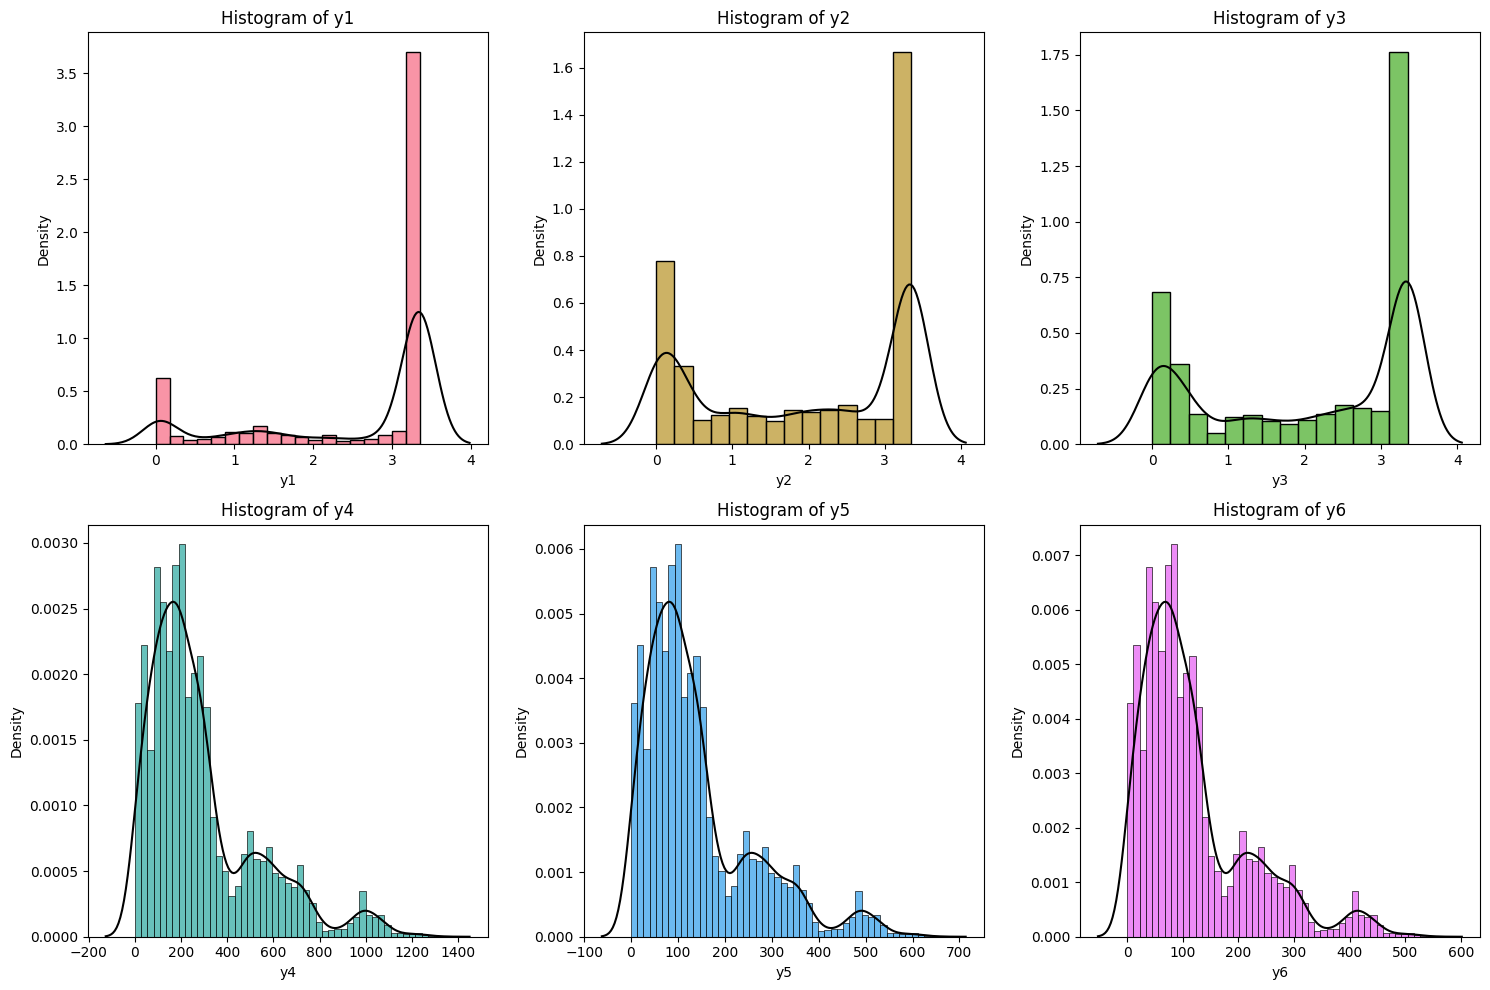

In [13]:
multiple_histplots(df)

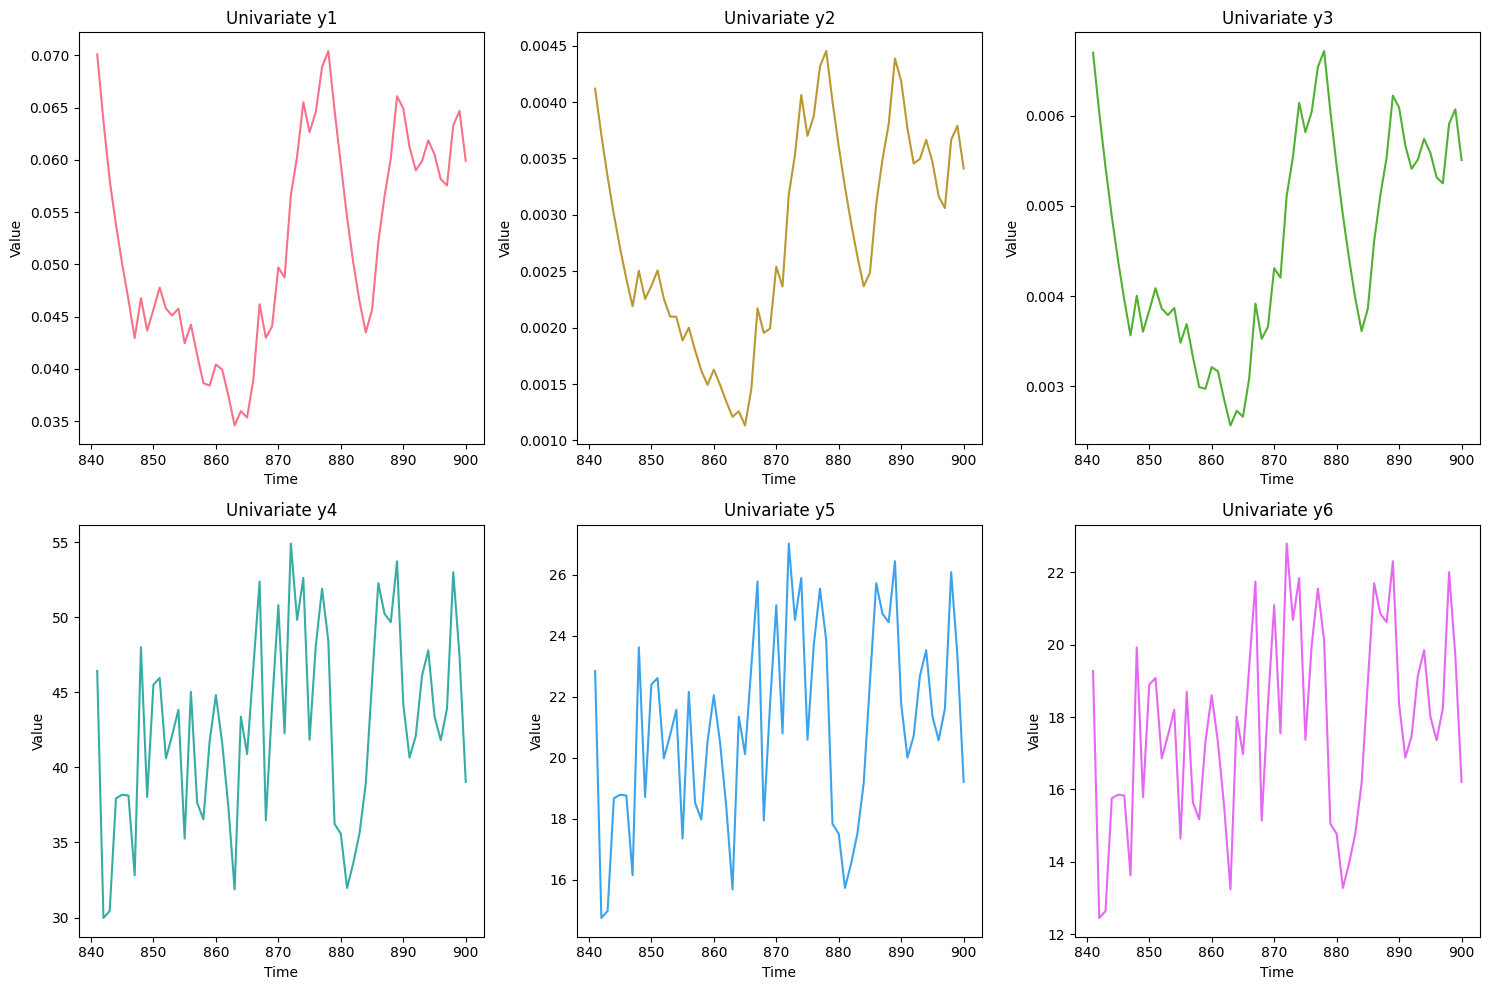

In [14]:
plot_ts(df, np.random.choice(np.arange(max(df['sample_no'] + 1)), 1)[0])

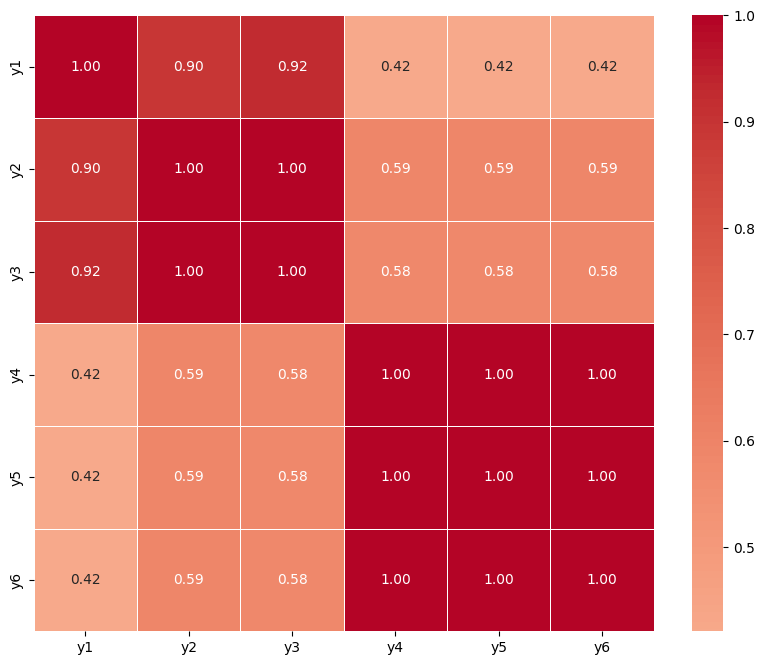

In [ ]:
correlation_ts(df)

Skipping y1 vs y2 for sample 1 due to constant value.
Skipping y1 vs y2 for sample 2 due to constant value.
Skipping y1 vs y2 for sample 3 due to constant value.
Skipping y1 vs y2 for sample 4 due to constant value.
Skipping y1 vs y2 for sample 5 due to constant value.
Skipping y1 vs y2 for sample 10 due to constant value.
Skipping y1 vs y2 for sample 12 due to constant value.
Skipping y1 vs y2 for sample 18 due to constant value.
Skipping y1 vs y2 for sample 20 due to constant value.
Skipping y1 vs y2 for sample 26 due to constant value.
Skipping y1 vs y2 for sample 28 due to constant value.
Skipping y1 vs y2 for sample 29 due to constant value.
Skipping y1 vs y2 for sample 31 due to constant value.
Skipping y1 vs y2 for sample 33 due to constant value.
Skipping y1 vs y2 for sample 34 due to constant value.
Skipping y1 vs y2 for sample 36 due to constant value.
Skipping y1 vs y2 for sample 38 due to constant value.
Skipping y1 vs y2 for sample 41 due to constant value.
Skipping y1 vs 

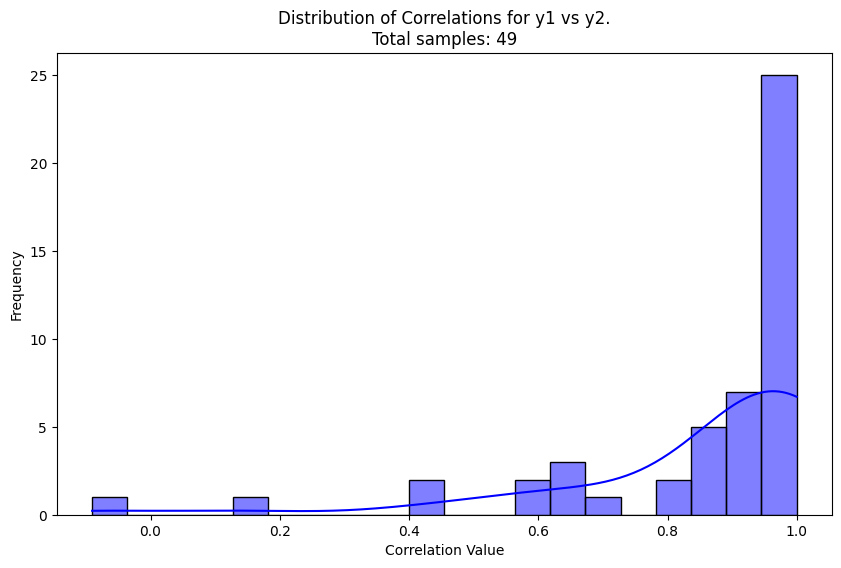

Skipping y1 vs y3 for sample 1 due to constant value.
Skipping y1 vs y3 for sample 2 due to constant value.
Skipping y1 vs y3 for sample 3 due to constant value.
Skipping y1 vs y3 for sample 4 due to constant value.
Skipping y1 vs y3 for sample 5 due to constant value.
Skipping y1 vs y3 for sample 10 due to constant value.
Skipping y1 vs y3 for sample 12 due to constant value.
Skipping y1 vs y3 for sample 18 due to constant value.
Skipping y1 vs y3 for sample 20 due to constant value.
Skipping y1 vs y3 for sample 26 due to constant value.
Skipping y1 vs y3 for sample 28 due to constant value.
Skipping y1 vs y3 for sample 29 due to constant value.
Skipping y1 vs y3 for sample 31 due to constant value.
Skipping y1 vs y3 for sample 33 due to constant value.
Skipping y1 vs y3 for sample 34 due to constant value.
Skipping y1 vs y3 for sample 36 due to constant value.
Skipping y1 vs y3 for sample 38 due to constant value.
Skipping y1 vs y3 for sample 41 due to constant value.
Skipping y1 vs 

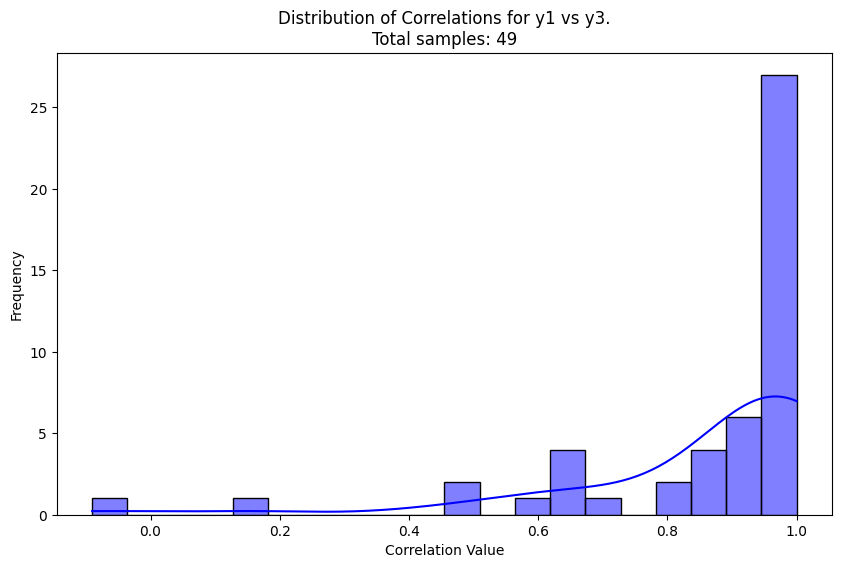

Skipping y1 vs y4 for sample 1 due to constant value.
Skipping y1 vs y4 for sample 2 due to constant value.
Skipping y1 vs y4 for sample 3 due to constant value.
Skipping y1 vs y4 for sample 4 due to constant value.
Skipping y1 vs y4 for sample 5 due to constant value.
Skipping y1 vs y4 for sample 10 due to constant value.
Skipping y1 vs y4 for sample 12 due to constant value.
Skipping y1 vs y4 for sample 18 due to constant value.
Skipping y1 vs y4 for sample 20 due to constant value.
Skipping y1 vs y4 for sample 26 due to constant value.
Skipping y1 vs y4 for sample 28 due to constant value.
Skipping y1 vs y4 for sample 29 due to constant value.
Skipping y1 vs y4 for sample 31 due to constant value.
Skipping y1 vs y4 for sample 33 due to constant value.
Skipping y1 vs y4 for sample 34 due to constant value.
Skipping y1 vs y4 for sample 36 due to constant value.
Skipping y1 vs y4 for sample 38 due to constant value.
Skipping y1 vs y4 for sample 41 due to constant value.
Skipping y1 vs 

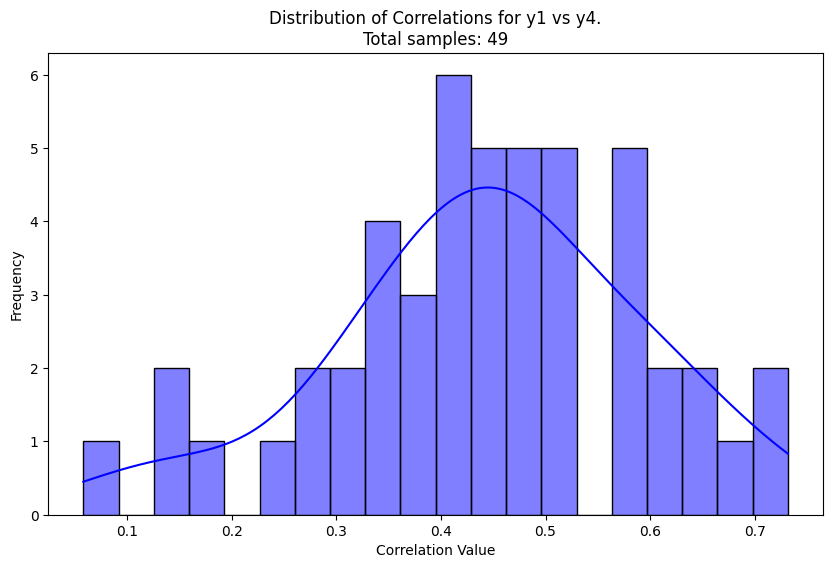

Skipping y1 vs y5 for sample 1 due to constant value.
Skipping y1 vs y5 for sample 2 due to constant value.
Skipping y1 vs y5 for sample 3 due to constant value.
Skipping y1 vs y5 for sample 4 due to constant value.
Skipping y1 vs y5 for sample 5 due to constant value.
Skipping y1 vs y5 for sample 10 due to constant value.
Skipping y1 vs y5 for sample 12 due to constant value.
Skipping y1 vs y5 for sample 18 due to constant value.
Skipping y1 vs y5 for sample 20 due to constant value.
Skipping y1 vs y5 for sample 26 due to constant value.
Skipping y1 vs y5 for sample 28 due to constant value.
Skipping y1 vs y5 for sample 29 due to constant value.
Skipping y1 vs y5 for sample 31 due to constant value.
Skipping y1 vs y5 for sample 33 due to constant value.
Skipping y1 vs y5 for sample 34 due to constant value.
Skipping y1 vs y5 for sample 36 due to constant value.
Skipping y1 vs y5 for sample 38 due to constant value.
Skipping y1 vs y5 for sample 41 due to constant value.
Skipping y1 vs 

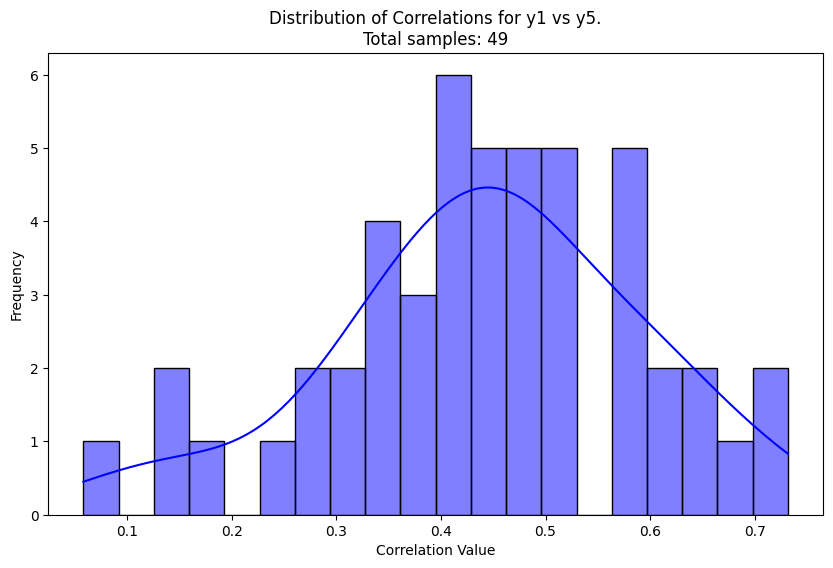

Skipping y1 vs y6 for sample 1 due to constant value.
Skipping y1 vs y6 for sample 2 due to constant value.
Skipping y1 vs y6 for sample 3 due to constant value.
Skipping y1 vs y6 for sample 4 due to constant value.
Skipping y1 vs y6 for sample 5 due to constant value.
Skipping y1 vs y6 for sample 10 due to constant value.
Skipping y1 vs y6 for sample 12 due to constant value.
Skipping y1 vs y6 for sample 18 due to constant value.
Skipping y1 vs y6 for sample 20 due to constant value.
Skipping y1 vs y6 for sample 26 due to constant value.
Skipping y1 vs y6 for sample 28 due to constant value.
Skipping y1 vs y6 for sample 29 due to constant value.
Skipping y1 vs y6 for sample 31 due to constant value.
Skipping y1 vs y6 for sample 33 due to constant value.
Skipping y1 vs y6 for sample 34 due to constant value.
Skipping y1 vs y6 for sample 36 due to constant value.
Skipping y1 vs y6 for sample 38 due to constant value.
Skipping y1 vs y6 for sample 41 due to constant value.
Skipping y1 vs 

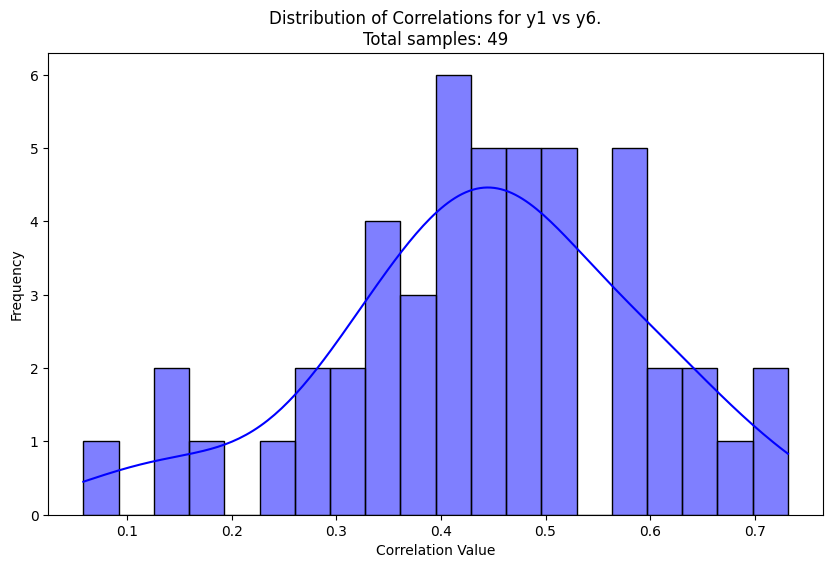

Skipping y2 vs y3 for sample 1 due to constant value.
Skipping y2 vs y3 for sample 2 due to constant value.
Skipping y2 vs y3 for sample 3 due to constant value.
Skipping y2 vs y3 for sample 4 due to constant value.
Skipping y2 vs y3 for sample 5 due to constant value.
Skipping y2 vs y3 for sample 10 due to constant value.
Skipping y2 vs y3 for sample 12 due to constant value.
Skipping y2 vs y3 for sample 18 due to constant value.
Skipping y2 vs y3 for sample 20 due to constant value.
Skipping y2 vs y3 for sample 26 due to constant value.
Skipping y2 vs y3 for sample 28 due to constant value.
Skipping y2 vs y3 for sample 29 due to constant value.
Skipping y2 vs y3 for sample 31 due to constant value.
Skipping y2 vs y3 for sample 33 due to constant value.
Skipping y2 vs y3 for sample 36 due to constant value.
Skipping y2 vs y3 for sample 38 due to constant value.
Skipping y2 vs y3 for sample 41 due to constant value.
Skipping y2 vs y3 for sample 44 due to constant value.
Skipping y2 vs 

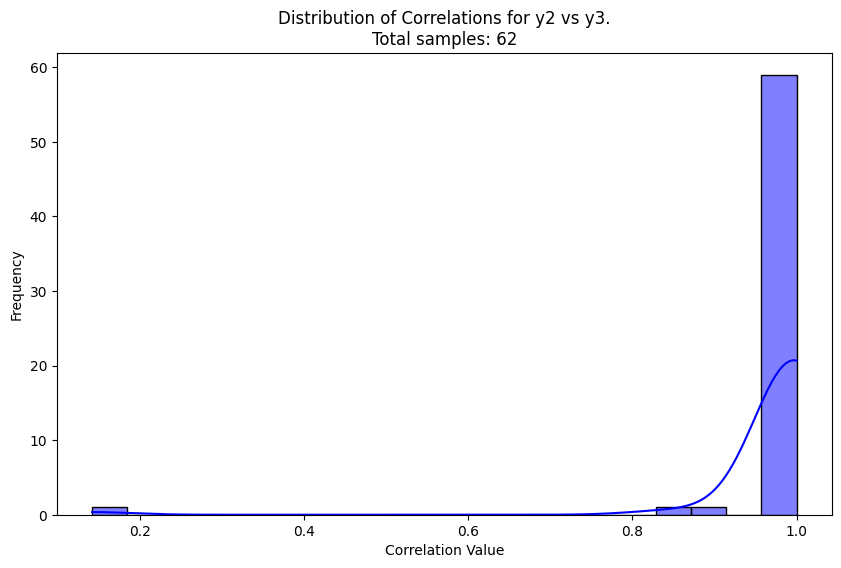

Skipping y2 vs y4 for sample 1 due to constant value.
Skipping y2 vs y4 for sample 2 due to constant value.
Skipping y2 vs y4 for sample 3 due to constant value.
Skipping y2 vs y4 for sample 4 due to constant value.
Skipping y2 vs y4 for sample 5 due to constant value.
Skipping y2 vs y4 for sample 10 due to constant value.
Skipping y2 vs y4 for sample 12 due to constant value.
Skipping y2 vs y4 for sample 18 due to constant value.
Skipping y2 vs y4 for sample 20 due to constant value.
Skipping y2 vs y4 for sample 28 due to constant value.
Skipping y2 vs y4 for sample 29 due to constant value.
Skipping y2 vs y4 for sample 31 due to constant value.
Skipping y2 vs y4 for sample 33 due to constant value.
Skipping y2 vs y4 for sample 36 due to constant value.
Skipping y2 vs y4 for sample 38 due to constant value.
Skipping y2 vs y4 for sample 41 due to constant value.
Skipping y2 vs y4 for sample 44 due to constant value.
Skipping y2 vs y4 for sample 46 due to constant value.
Skipping y2 vs 

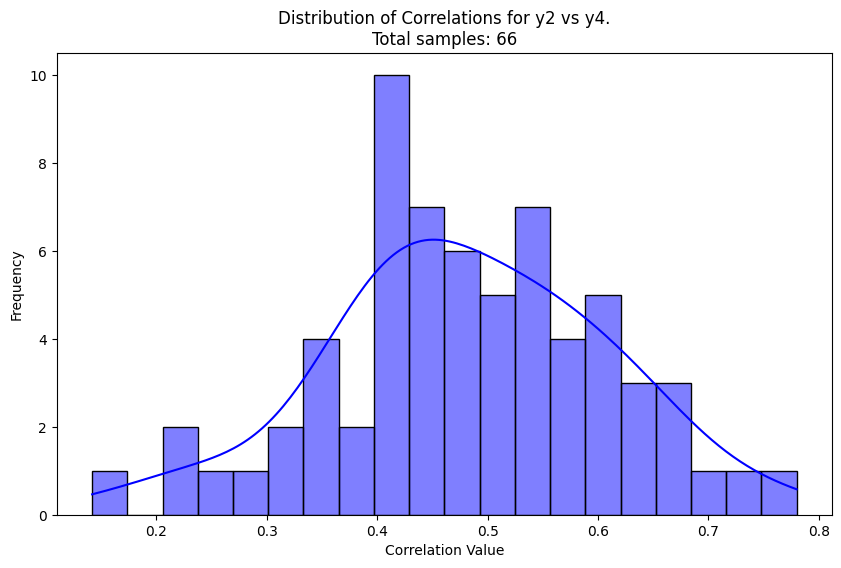

Skipping y2 vs y5 for sample 1 due to constant value.
Skipping y2 vs y5 for sample 2 due to constant value.
Skipping y2 vs y5 for sample 3 due to constant value.
Skipping y2 vs y5 for sample 4 due to constant value.
Skipping y2 vs y5 for sample 5 due to constant value.
Skipping y2 vs y5 for sample 10 due to constant value.
Skipping y2 vs y5 for sample 12 due to constant value.
Skipping y2 vs y5 for sample 18 due to constant value.
Skipping y2 vs y5 for sample 20 due to constant value.
Skipping y2 vs y5 for sample 28 due to constant value.
Skipping y2 vs y5 for sample 29 due to constant value.
Skipping y2 vs y5 for sample 31 due to constant value.
Skipping y2 vs y5 for sample 33 due to constant value.
Skipping y2 vs y5 for sample 36 due to constant value.
Skipping y2 vs y5 for sample 38 due to constant value.
Skipping y2 vs y5 for sample 41 due to constant value.
Skipping y2 vs y5 for sample 44 due to constant value.
Skipping y2 vs y5 for sample 46 due to constant value.
Skipping y2 vs 

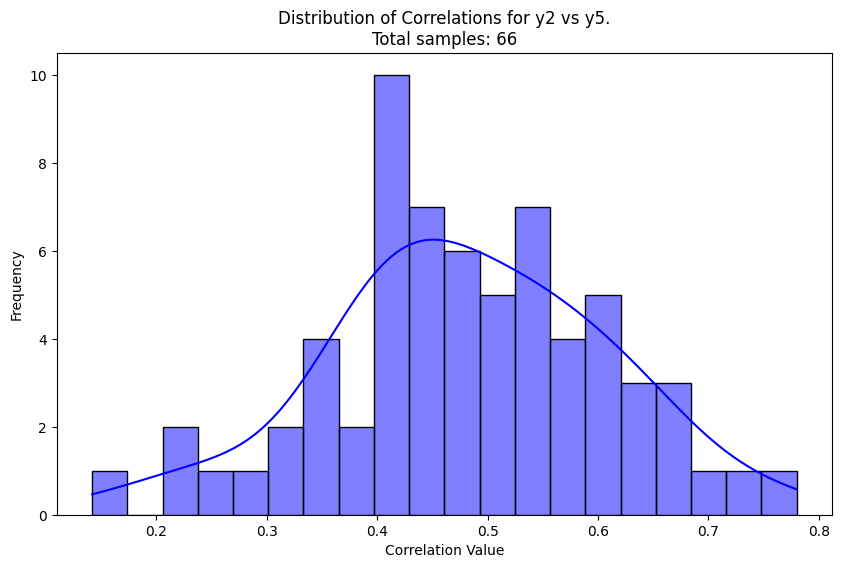

Skipping y2 vs y6 for sample 1 due to constant value.
Skipping y2 vs y6 for sample 2 due to constant value.
Skipping y2 vs y6 for sample 3 due to constant value.
Skipping y2 vs y6 for sample 4 due to constant value.
Skipping y2 vs y6 for sample 5 due to constant value.
Skipping y2 vs y6 for sample 10 due to constant value.
Skipping y2 vs y6 for sample 12 due to constant value.
Skipping y2 vs y6 for sample 18 due to constant value.
Skipping y2 vs y6 for sample 20 due to constant value.
Skipping y2 vs y6 for sample 28 due to constant value.
Skipping y2 vs y6 for sample 29 due to constant value.
Skipping y2 vs y6 for sample 31 due to constant value.
Skipping y2 vs y6 for sample 33 due to constant value.
Skipping y2 vs y6 for sample 36 due to constant value.
Skipping y2 vs y6 for sample 38 due to constant value.
Skipping y2 vs y6 for sample 41 due to constant value.
Skipping y2 vs y6 for sample 44 due to constant value.
Skipping y2 vs y6 for sample 46 due to constant value.
Skipping y2 vs 

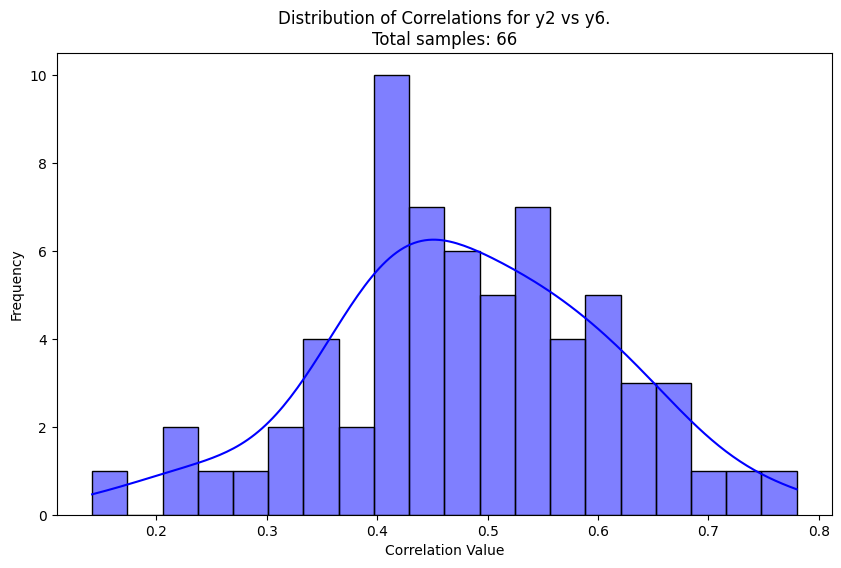

Skipping y3 vs y4 for sample 1 due to constant value.
Skipping y3 vs y4 for sample 2 due to constant value.
Skipping y3 vs y4 for sample 3 due to constant value.
Skipping y3 vs y4 for sample 4 due to constant value.
Skipping y3 vs y4 for sample 5 due to constant value.
Skipping y3 vs y4 for sample 10 due to constant value.
Skipping y3 vs y4 for sample 12 due to constant value.
Skipping y3 vs y4 for sample 18 due to constant value.
Skipping y3 vs y4 for sample 20 due to constant value.
Skipping y3 vs y4 for sample 26 due to constant value.
Skipping y3 vs y4 for sample 28 due to constant value.
Skipping y3 vs y4 for sample 29 due to constant value.
Skipping y3 vs y4 for sample 31 due to constant value.
Skipping y3 vs y4 for sample 33 due to constant value.
Skipping y3 vs y4 for sample 36 due to constant value.
Skipping y3 vs y4 for sample 38 due to constant value.
Skipping y3 vs y4 for sample 41 due to constant value.
Skipping y3 vs y4 for sample 44 due to constant value.
Skipping y3 vs 

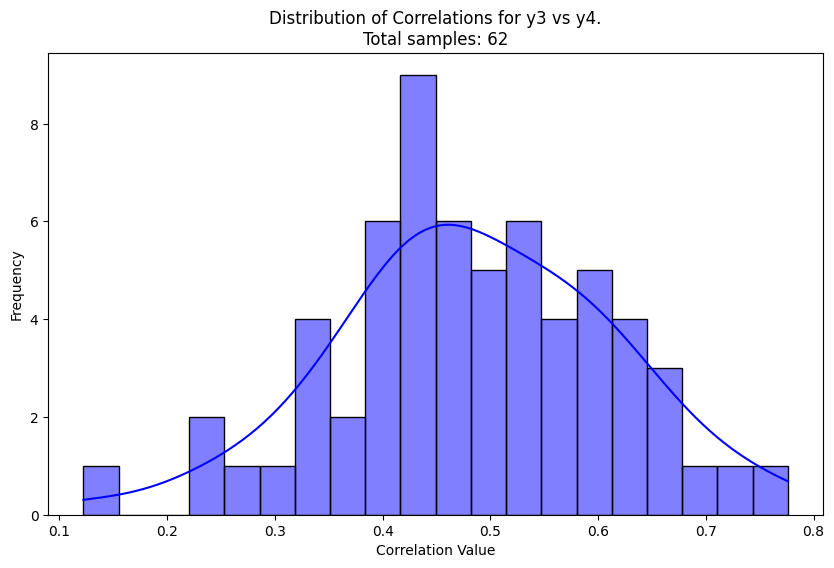

Skipping y3 vs y5 for sample 1 due to constant value.
Skipping y3 vs y5 for sample 2 due to constant value.
Skipping y3 vs y5 for sample 3 due to constant value.
Skipping y3 vs y5 for sample 4 due to constant value.
Skipping y3 vs y5 for sample 5 due to constant value.
Skipping y3 vs y5 for sample 10 due to constant value.
Skipping y3 vs y5 for sample 12 due to constant value.
Skipping y3 vs y5 for sample 18 due to constant value.
Skipping y3 vs y5 for sample 20 due to constant value.
Skipping y3 vs y5 for sample 26 due to constant value.
Skipping y3 vs y5 for sample 28 due to constant value.
Skipping y3 vs y5 for sample 29 due to constant value.
Skipping y3 vs y5 for sample 31 due to constant value.
Skipping y3 vs y5 for sample 33 due to constant value.
Skipping y3 vs y5 for sample 36 due to constant value.
Skipping y3 vs y5 for sample 38 due to constant value.
Skipping y3 vs y5 for sample 41 due to constant value.
Skipping y3 vs y5 for sample 44 due to constant value.
Skipping y3 vs 

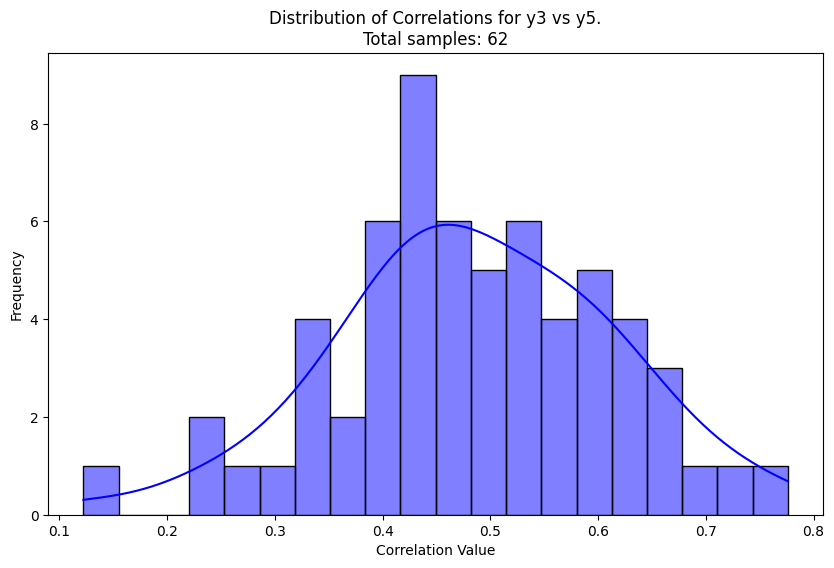

Skipping y3 vs y6 for sample 1 due to constant value.
Skipping y3 vs y6 for sample 2 due to constant value.
Skipping y3 vs y6 for sample 3 due to constant value.
Skipping y3 vs y6 for sample 4 due to constant value.
Skipping y3 vs y6 for sample 5 due to constant value.
Skipping y3 vs y6 for sample 10 due to constant value.
Skipping y3 vs y6 for sample 12 due to constant value.
Skipping y3 vs y6 for sample 18 due to constant value.
Skipping y3 vs y6 for sample 20 due to constant value.
Skipping y3 vs y6 for sample 26 due to constant value.
Skipping y3 vs y6 for sample 28 due to constant value.
Skipping y3 vs y6 for sample 29 due to constant value.
Skipping y3 vs y6 for sample 31 due to constant value.
Skipping y3 vs y6 for sample 33 due to constant value.
Skipping y3 vs y6 for sample 36 due to constant value.
Skipping y3 vs y6 for sample 38 due to constant value.
Skipping y3 vs y6 for sample 41 due to constant value.
Skipping y3 vs y6 for sample 44 due to constant value.
Skipping y3 vs 

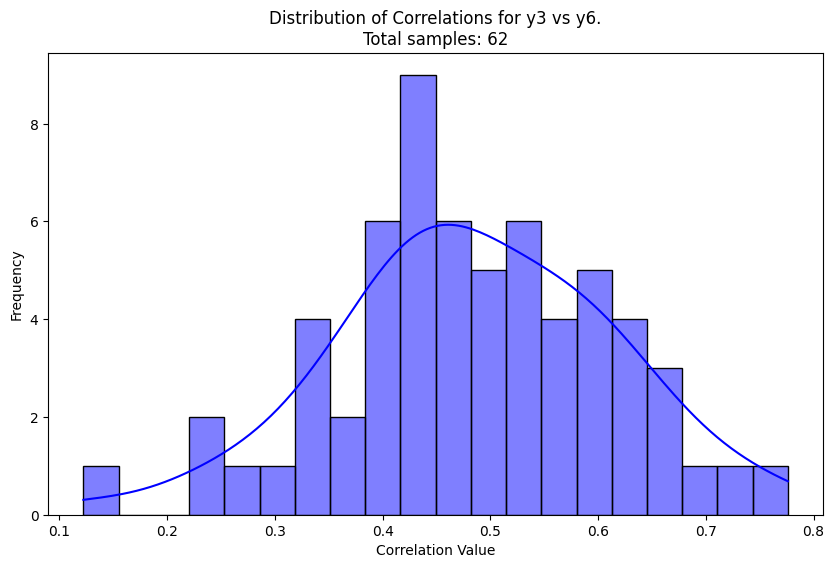

ValueError: Too many bins for data range. Cannot create 20 finite-sized bins.

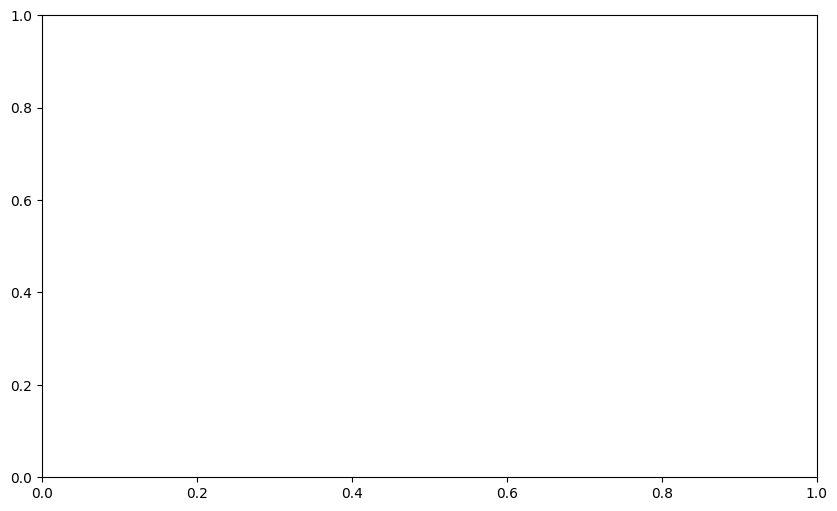

In [7]:
correlation_distribution(df)

c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users

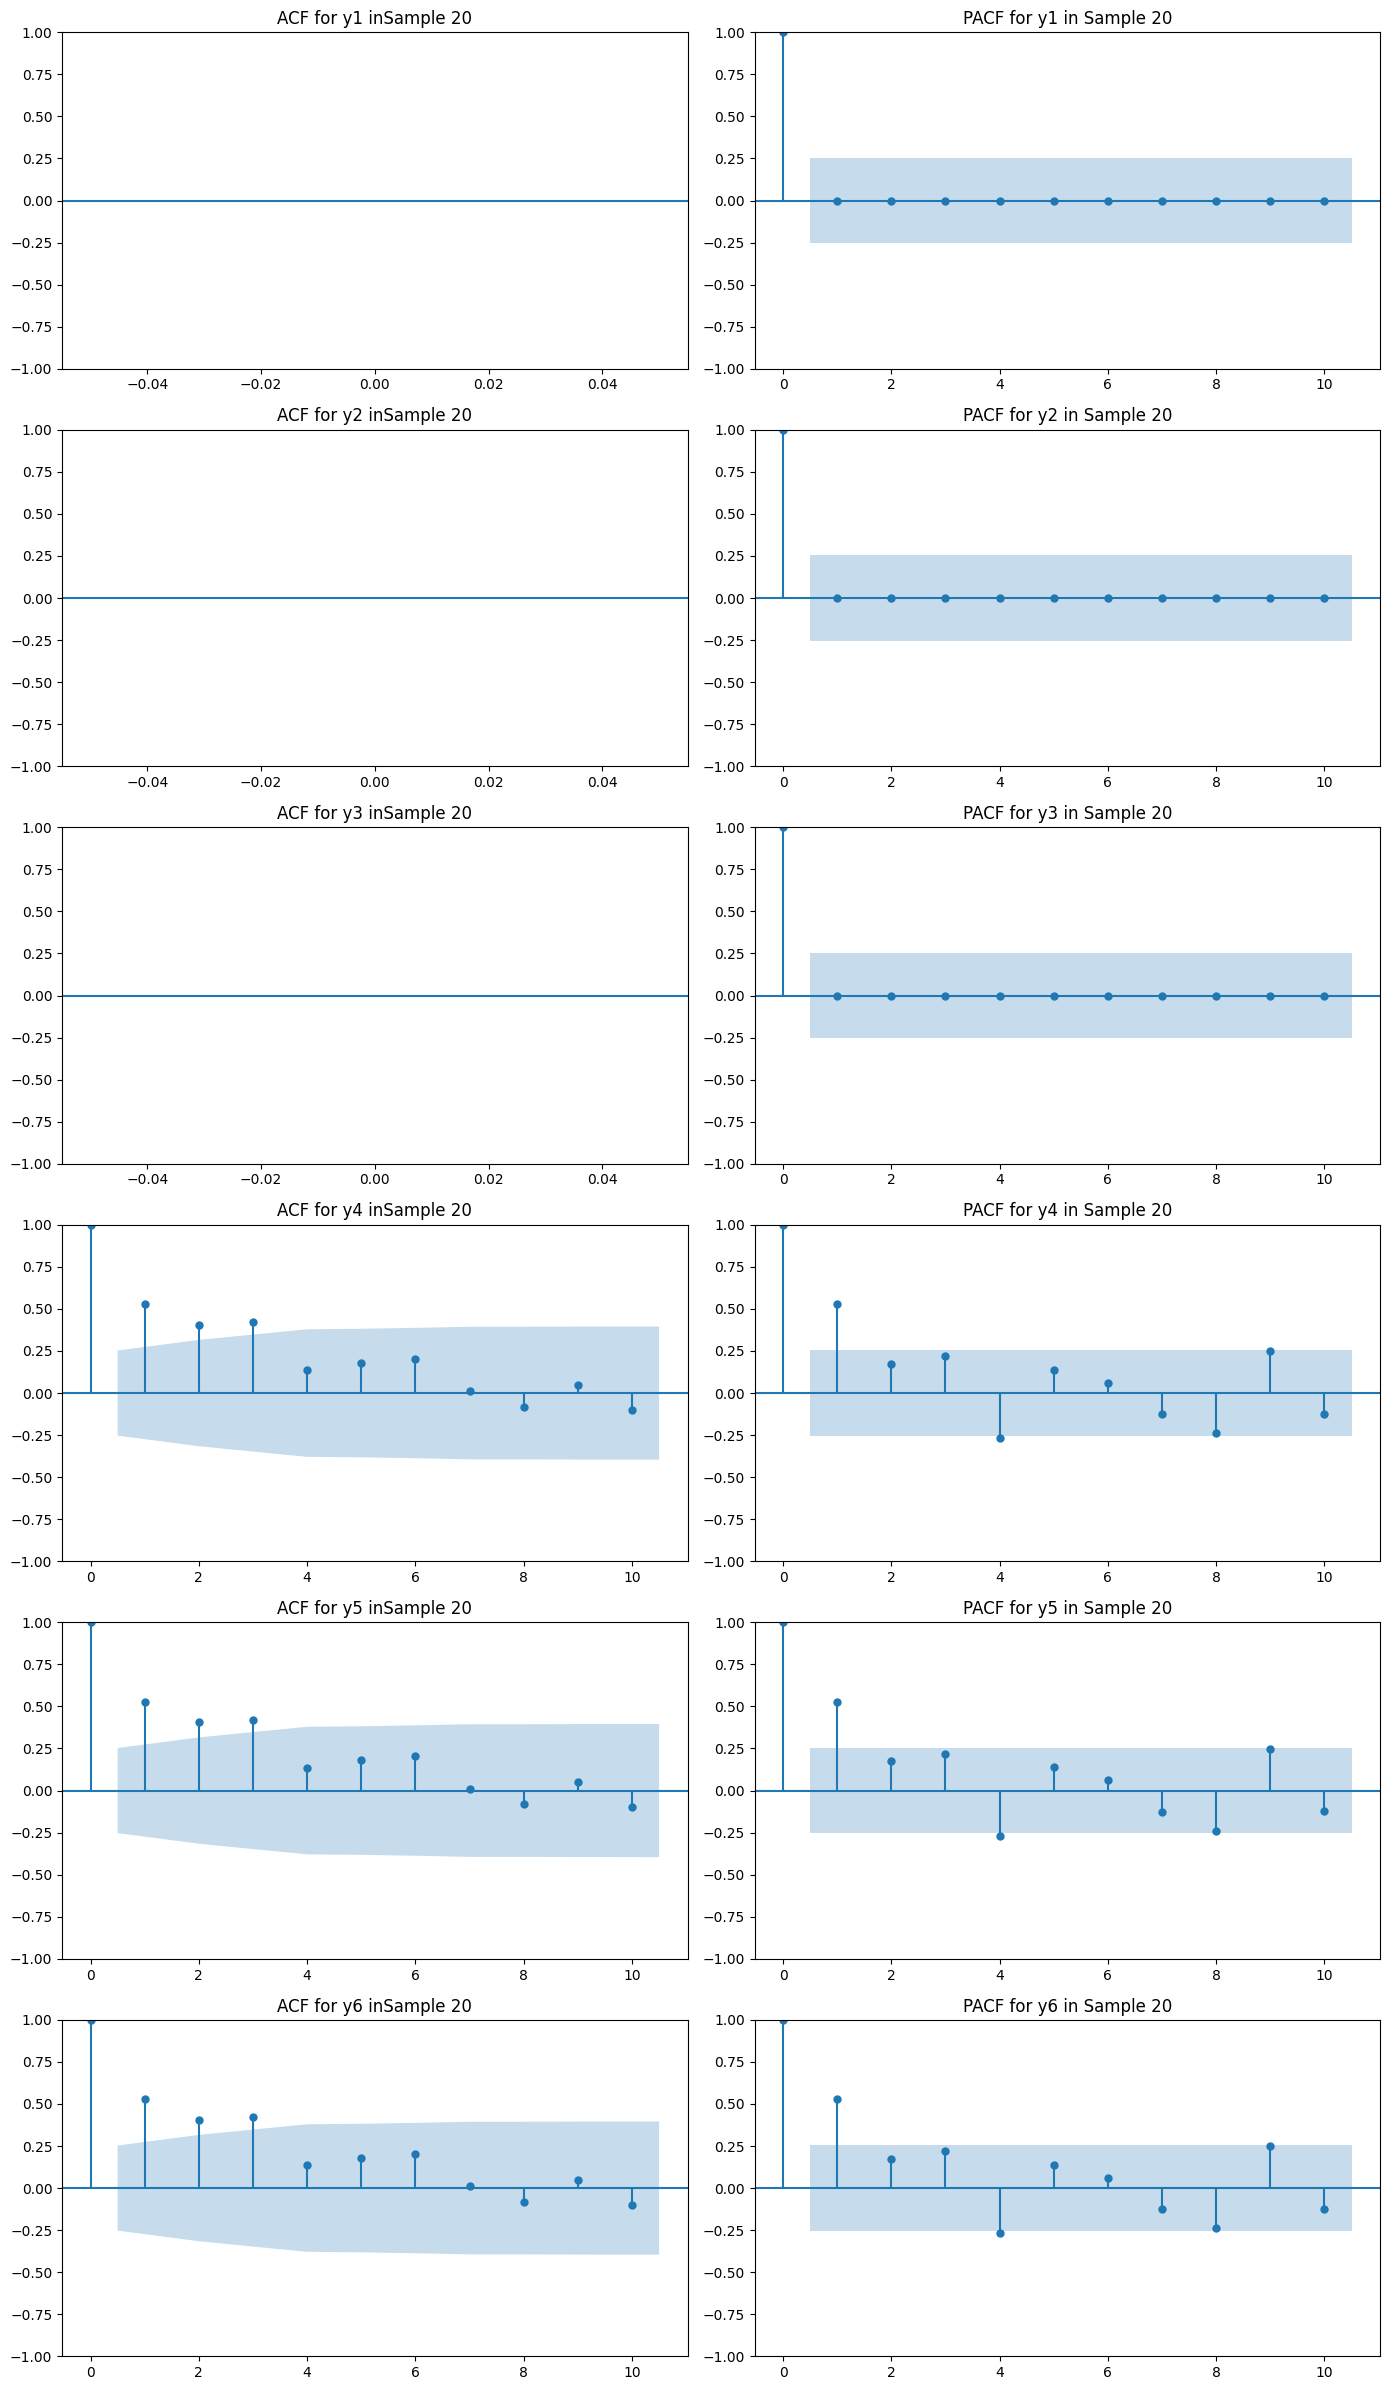

In [11]:
plot_acf_pacf(df)

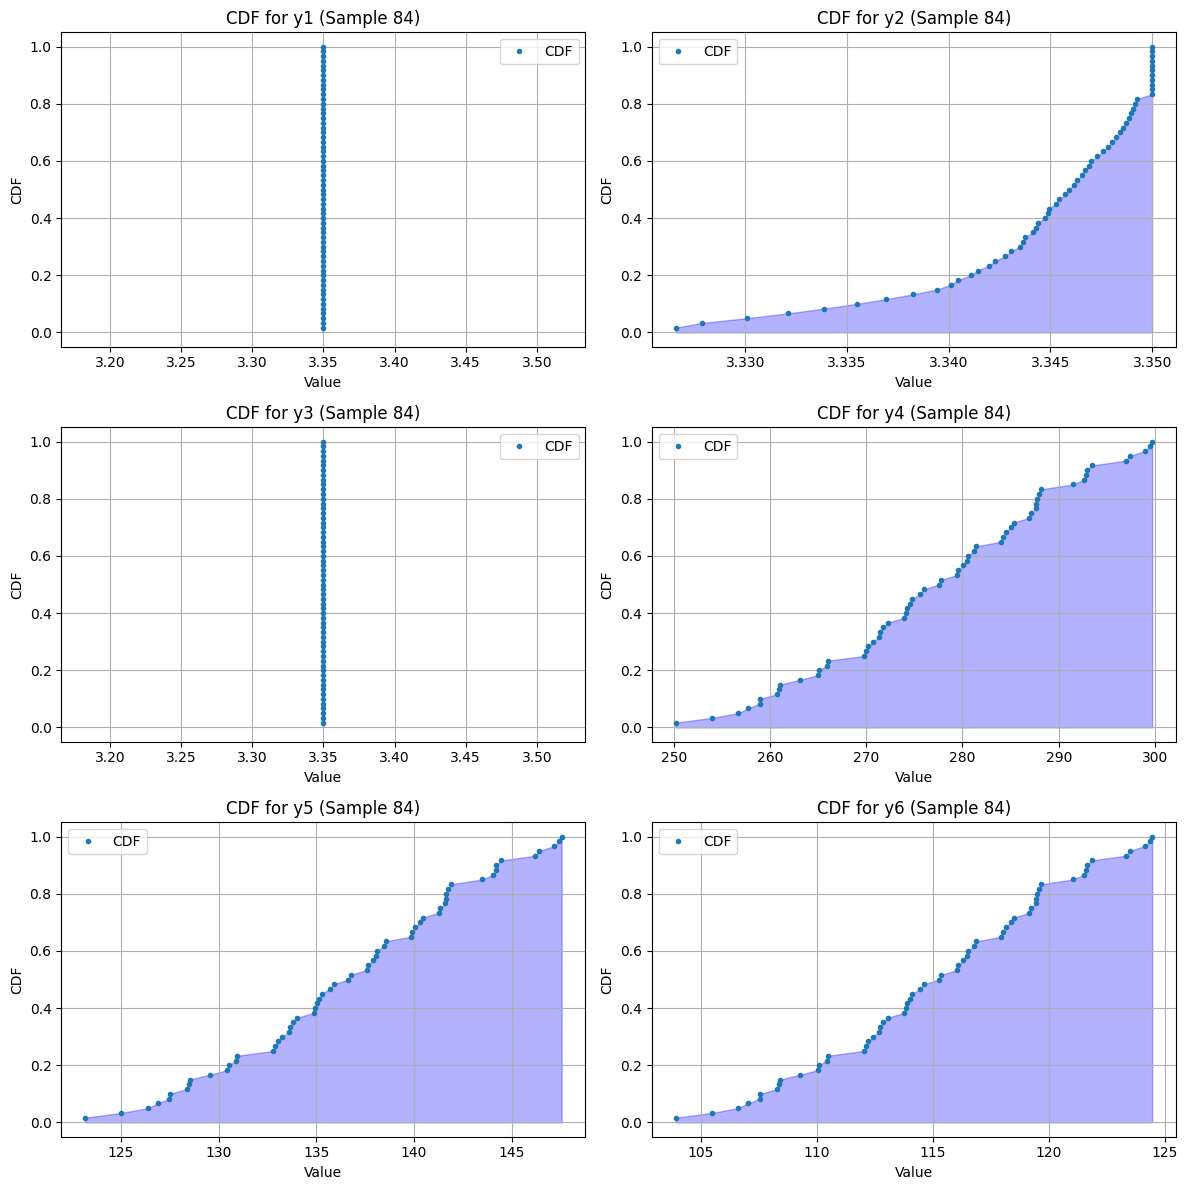

In [44]:
plot_cdf(df)

c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
c:\Users\Alex\Desktop\NASA-UQ-Challenge\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Alex\Desktop\NASA

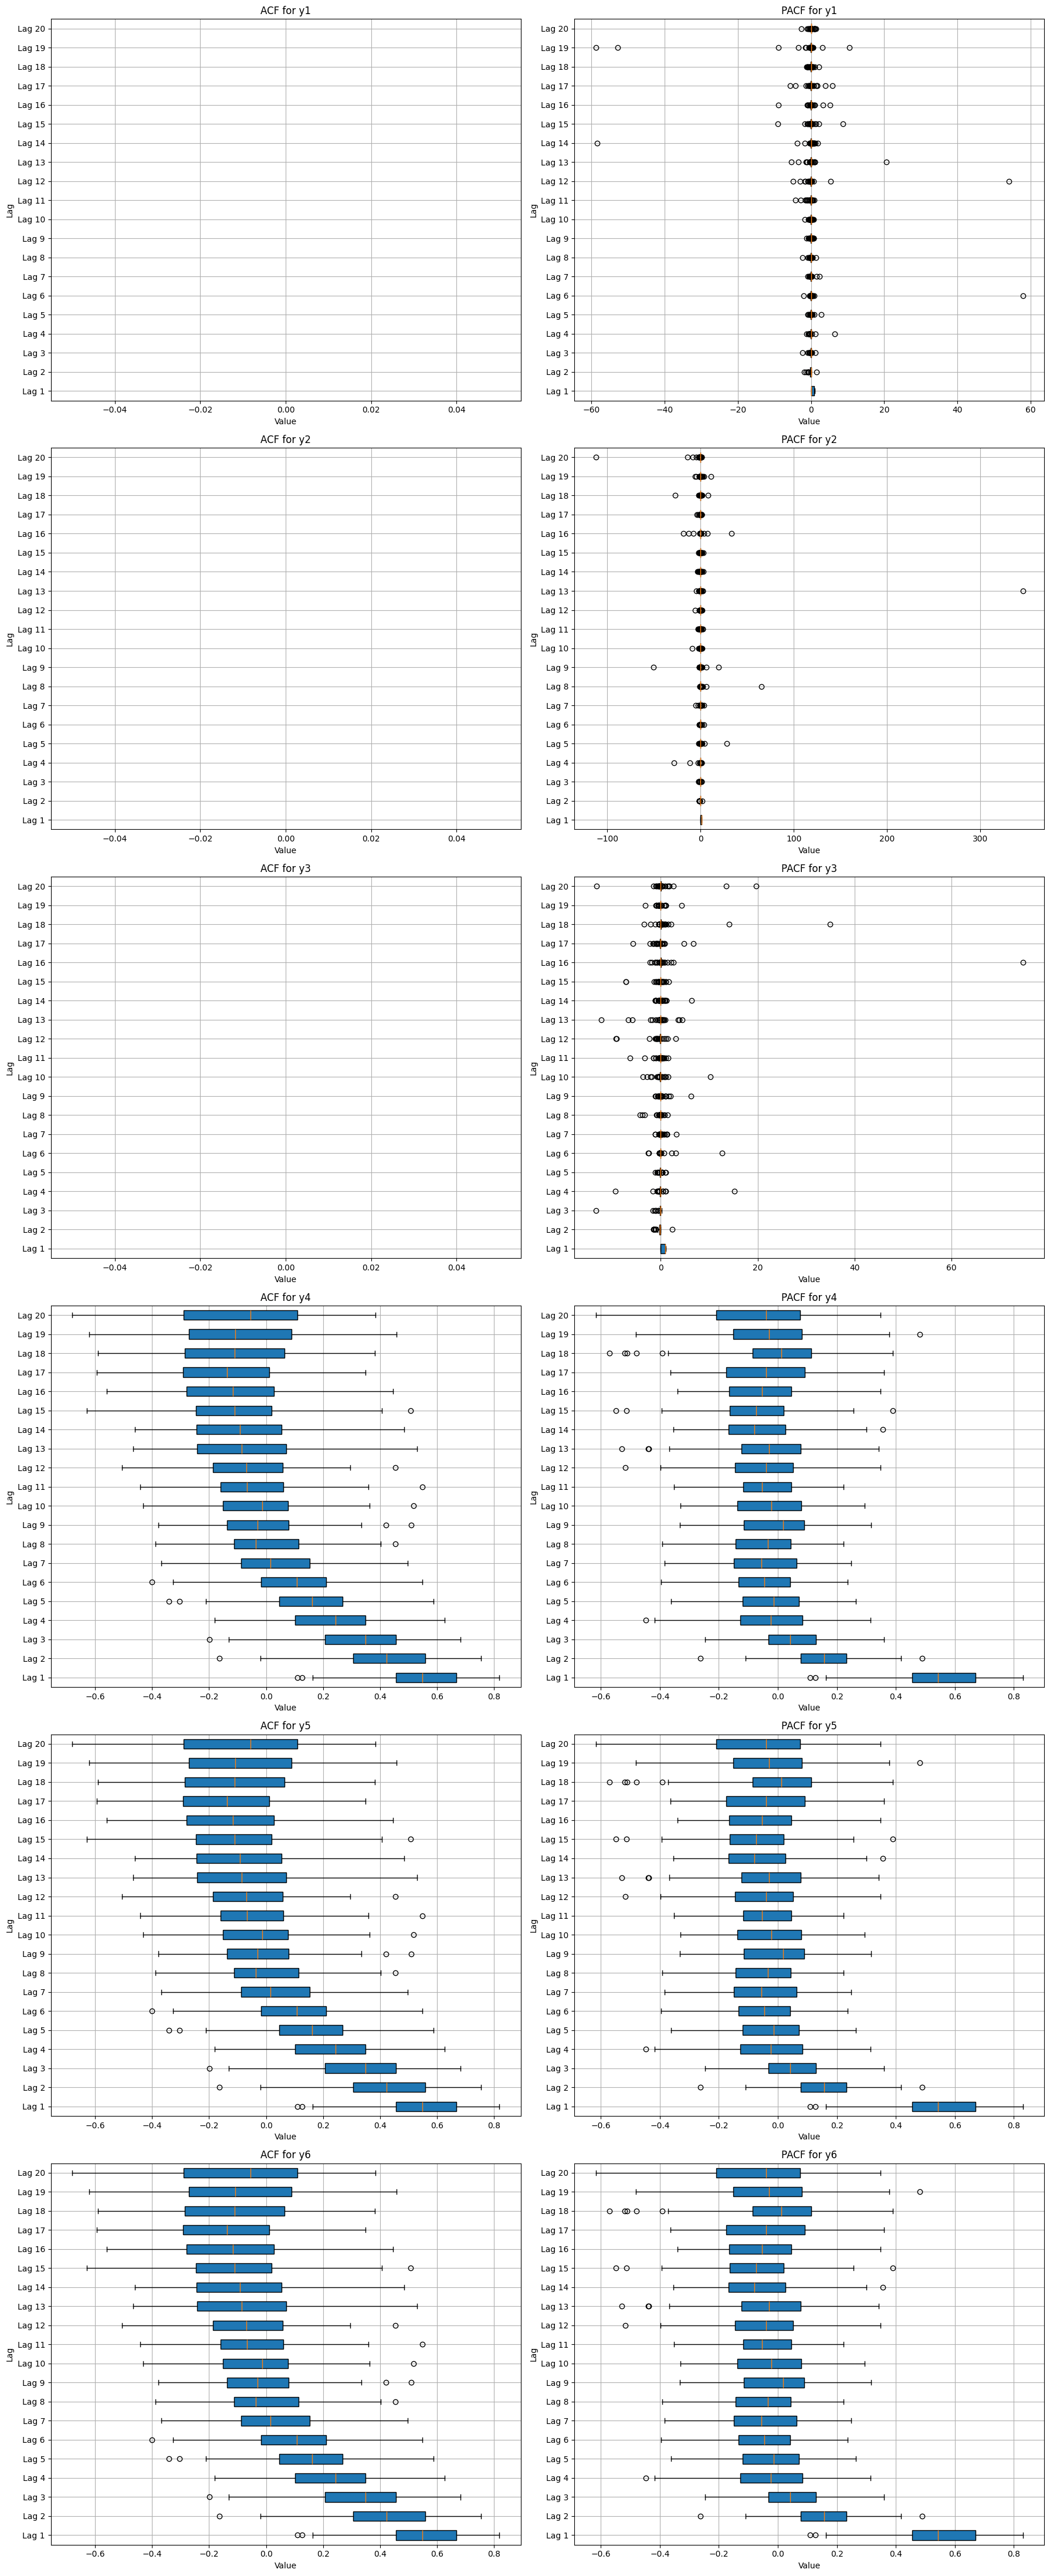

In [14]:
boxplot_autocorrelation(df, lag_period=20)

# Key Insights:

1. y4, y5 and y6 are the "same" thing.
2. Ts is entirely dependant on y1,y2,y3 and y4.
